# Sierpiński Gasket Using Binary Addresses

This notebook implements and analyses the Sierpiński gasket using
binary coordinate addresses and PyTorch tensor operations.

The project demonstrates tensor parallelism, visualisation,
performance comparison, and fractal-dimension analysis.

In [22]:
import torch
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:", device)

PyTorch version: 2.13.0
Selected device: mps


## Binary-address rule

The Sierpiński gasket can be revealed through the parity pattern of
Pascal's triangle. A cell at row `n` and position `k` is odd when:

\[
k \;\&\; (n-k) = 0
\]

Here, `&` denotes the bitwise AND operation. This test avoids computing
the potentially very large binomial coefficient directly.

In [23]:
# Number of rows in Pascal's triangle
size = 256

# Integer addresses created directly on the selected device
indices = torch.arange(
    size,
    dtype=torch.int32,
    device=device
)

# Rows have shape (256, 1); columns have shape (1, 256)
rows = indices[:, None]
columns = indices[None, :]

# Only positions inside Pascal's triangular region are valid
valid_region = columns <= rows

# A Pascal cell is odd when no binary 1-bits overlap
binary_test = torch.bitwise_and(
    columns,
    rows - columns
) == 0

gasket = valid_region & binary_test

print("Gasket shape:", gasket.shape)
print("Gasket data type:", gasket.dtype)
print("Gasket device:", gasket.device)
print("Number of active points:", gasket.sum().item())

Gasket shape: torch.Size([256, 256])
Gasket data type: torch.bool
Gasket device: mps:0
Number of active points: 6561


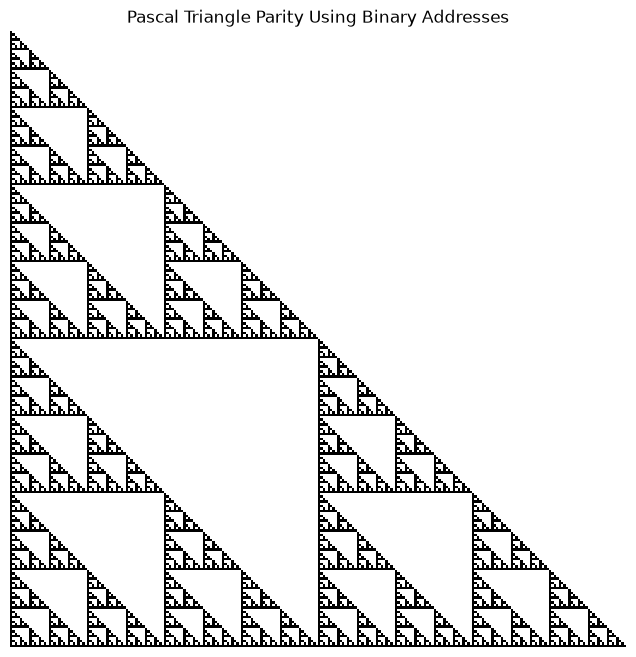

In [24]:
plt.figure(figsize=(8, 8))

plt.imshow(
    gasket.cpu().numpy(),
    cmap="binary",
    interpolation="nearest"
)

plt.title("Pascal Triangle Parity Using Binary Addresses")
plt.axis("off")
plt.show()

## Centred Sierpiński gasket

The binary-address calculation produces a left-aligned Pascal triangle.
For visualisation, each active cell at row `n` and position `k` is
mapped to the centred horizontal coordinate

\[
x = (N - 1 - n) + 2k
\]

This changes only the display coordinates. The membership of every
point is still determined by the binary-address test.

In [25]:
# Find the addresses of all active points
active_rows, active_columns = torch.where(gasket)

# Create a wider canvas for a centred triangle
centred_gasket = torch.zeros(
    (size, 2 * size - 1),
    dtype=torch.bool,
    device=device
)

# Convert Pascal addresses into centred display coordinates
centred_columns = (
    size - 1 - active_rows
    + 2 * active_columns
)

# Place the active points on the centred canvas
centred_gasket[
    active_rows,
    centred_columns
] = True

print("Centred image shape:", centred_gasket.shape)
print("Centred image device:", centred_gasket.device)
print("Number of active points:", centred_gasket.sum().item())

Centred image shape: torch.Size([256, 511])
Centred image device: mps:0
Number of active points: 6561


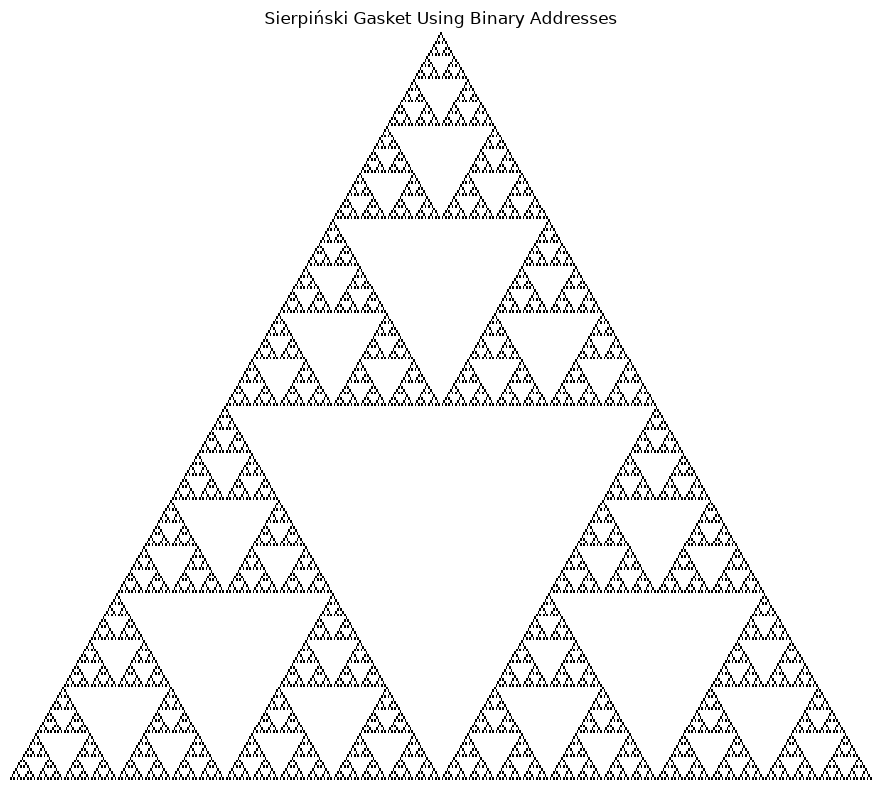

In [26]:
plt.figure(figsize=(10, 8))

plt.imshow(
    centred_gasket.cpu().numpy(),
    cmap="binary",
    interpolation="nearest",
    aspect=3 ** 0.5
)

plt.title("Sierpiński Gasket Using Binary Addresses")
plt.axis("off")
plt.tight_layout()
plt.show()

## Reusable PyTorch implementation

The generation process is placed inside a function so that different
image resolutions and computational devices can be tested consistently.
All pixel addresses are evaluated simultaneously using PyTorch tensor
operations, without a Python loop over individual pixels.

In [27]:
def generate_sierpinski(size, computation_device):
    """
    Generate raw and centred Sierpiński gasket masks using
    the binary-address test.

    Parameters
    ----------
    size : int
        Number of rows in Pascal's triangle.
    computation_device : torch.device
        Device used for tensor calculations.

    Returns
    -------
    raw_gasket : torch.Tensor
        Left-aligned Pascal parity mask.
    centred_gasket : torch.Tensor
        Centred visualisation mask.
    """
    if not isinstance(size, int) or size < 2:
        raise ValueError("size must be an integer greater than 1")

    indices = torch.arange(
        size,
        dtype=torch.int32,
        device=computation_device
    )

    rows = indices[:, None]
    columns = indices[None, :]

    valid_region = columns <= rows

    binary_test = torch.bitwise_and(
        columns,
        rows - columns
    ) == 0

    raw_gasket = valid_region & binary_test

    active_rows, active_columns = torch.where(raw_gasket)

    centred_gasket = torch.zeros(
        (size, 2 * size - 1),
        dtype=torch.bool,
        device=computation_device
    )

    centred_columns = (
        size - 1 - active_rows
        + 2 * active_columns
    )

    centred_gasket[
        active_rows,
        centred_columns
    ] = True

    return raw_gasket, centred_gasket

In [28]:
high_resolution_size = 1024

raw_high_res, centred_high_res = generate_sierpinski(
    high_resolution_size,
    device
)

print("Raw shape:", raw_high_res.shape)
print("Centred shape:", centred_high_res.shape)
print("Device:", centred_high_res.device)
print("Active points:", centred_high_res.sum().item())

Raw shape: torch.Size([1024, 1024])
Centred shape: torch.Size([1024, 2047])
Device: mps:0
Active points: 59049


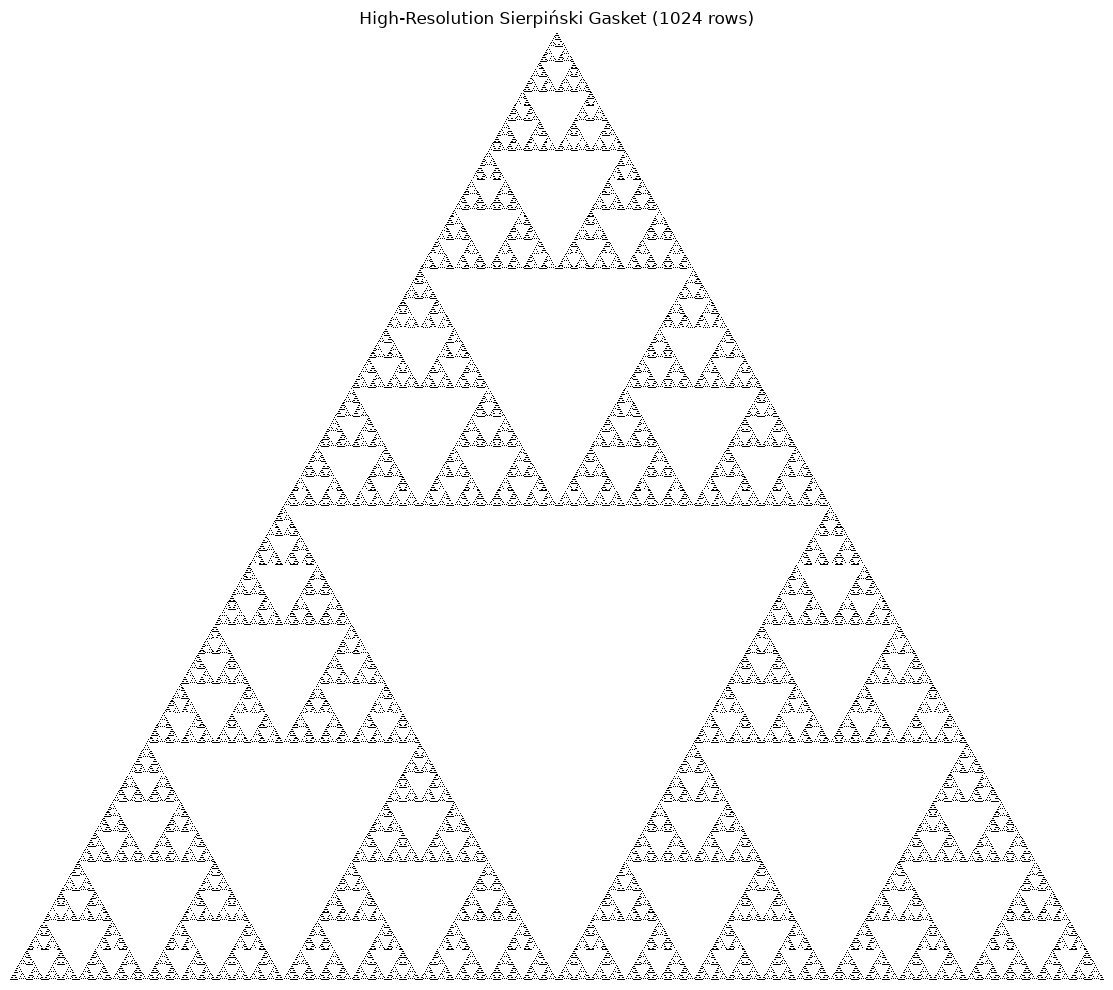

In [29]:
plt.figure(figsize=(12, 10))

plt.imshow(
    centred_high_res.cpu().numpy(),
    cmap="binary",
    interpolation="nearest",
    aspect=3 ** 0.5
)

plt.title(
    f"High-Resolution Sierpiński Gasket "
    f"({high_resolution_size} rows)"
)

plt.axis("off")
plt.tight_layout()
plt.show()

## Robust CPU and MPS performance comparison

The same vectorised PyTorch implementation is benchmarked on CPU and
Apple MPS across multiple image sizes.

For each size and device:

- three warm-up runs are performed;
- twenty measured runs are collected;
- MPS is synchronised before and after timing;
- the device testing order is randomised;
- the median is used as the representative time;
- the interquartile range shows timing variability.

The Sierpiński generation itself is deterministic. Any variation in
execution time is caused by factors such as device scheduling, memory
allocation, temperature, and background system activity.

In [30]:
import time
import random
import numpy as np


def synchronise_device(computation_device):
    """
    Wait until asynchronous operations on the selected device
    have completed.
    """
    if computation_device.type == "mps":
        torch.mps.synchronize()

    elif computation_device.type == "cuda":
        torch.cuda.synchronize()

In [31]:
def benchmark_distribution(
    size,
    computation_device,
    repeats=20,
    warmups=3
):
    """
    Benchmark Sierpiński generation repeatedly.

    Parameters
    ----------
    size : int
        Number of Pascal-triangle rows.

    computation_device : torch.device
        CPU, MPS, or CUDA device used for generation.

    repeats : int
        Number of measured runs.

    warmups : int
        Number of unmeasured warm-up runs.

    Returns
    -------
    numpy.ndarray
        Individual execution times in milliseconds.
    """

    # Warm-up runs reduce one-time initialisation effects
    for _ in range(warmups):
        warmup_raw, warmup_centred = generate_sierpinski(
            size,
            computation_device
        )

        synchronise_device(computation_device)

        del warmup_raw, warmup_centred

    elapsed_times = []

    # Collect repeated timing measurements
    for _ in range(repeats):
        synchronise_device(computation_device)

        start_time = time.perf_counter_ns()

        result_raw, result_centred = generate_sierpinski(
            size,
            computation_device
        )

        synchronise_device(computation_device)

        end_time = time.perf_counter_ns()

        elapsed_milliseconds = (
            end_time - start_time
        ) / 1_000_000

        elapsed_times.append(elapsed_milliseconds)

        del result_raw, result_centred

    return np.array(elapsed_times)

In [32]:
# More checkpoints give a clearer performance trend
benchmark_sizes = [
    256,
    384,
    512,
    768,
    1024,
    1536,
    2048,
    2560,
    3072,
    3584,
    4096
]

cpu_device = torch.device("cpu")
accelerator_device = device
accelerator_label = accelerator_device.type.upper()

repeats = 20
warmups = 3

# Store every individual timing measurement
timing_samples = {
    "CPU": {},
    accelerator_label: {}
}

# Reproducible randomisation of device testing order
random_generator = random.Random(3710)

print("Benchmark configuration")
print("-----------------------")
print("Sizes:", benchmark_sizes)
print("Measured runs per configuration:", repeats)
print("Warm-up runs per configuration:", warmups)
print("Accelerator:", accelerator_label)

Benchmark configuration
-----------------------
Sizes: [256, 384, 512, 768, 1024, 1536, 2048, 2560, 3072, 3584, 4096]
Measured runs per configuration: 20
Warm-up runs per configuration: 3
Accelerator: MPS


In [33]:
for benchmark_size in benchmark_sizes:

    devices_to_test = [
        ("CPU", cpu_device),
        (accelerator_label, accelerator_device)
    ]

    # Avoid always testing one device first
    random_generator.shuffle(devices_to_test)

    for label, test_device in devices_to_test:
        timing_samples[label][benchmark_size] = (
            benchmark_distribution(
                size=benchmark_size,
                computation_device=test_device,
                repeats=repeats,
                warmups=warmups
            )
        )

    cpu_samples = timing_samples["CPU"][benchmark_size]

    accelerator_samples = timing_samples[
        accelerator_label
    ][benchmark_size]

    cpu_median = np.median(cpu_samples)

    accelerator_median = np.median(
        accelerator_samples
    )

    print(
        f"Size {benchmark_size:4d}: "
        f"CPU median = {cpu_median:8.3f} ms, "
        f"{accelerator_label} median = "
        f"{accelerator_median:8.3f} ms"
    )

Size  256: CPU median =    0.240 ms, MPS median =    1.328 ms
Size  384: CPU median =    0.276 ms, MPS median =    1.107 ms
Size  512: CPU median =    0.346 ms, MPS median =    1.088 ms
Size  768: CPU median =    0.708 ms, MPS median =    2.538 ms
Size 1024: CPU median =    1.199 ms, MPS median =    2.112 ms
Size 1536: CPU median =    2.217 ms, MPS median =    2.746 ms
Size 2048: CPU median =    4.176 ms, MPS median =    3.696 ms
Size 2560: CPU median =    6.223 ms, MPS median =    5.834 ms
Size 3072: CPU median =    8.863 ms, MPS median =    7.411 ms
Size 3584: CPU median =   12.629 ms, MPS median =    9.936 ms
Size 4096: CPU median =   15.943 ms, MPS median =   12.731 ms


In [34]:
benchmark_summary = {}

for label in ["CPU", accelerator_label]:

    medians = []
    lower_quartiles = []
    upper_quartiles = []

    for benchmark_size in benchmark_sizes:

        samples = timing_samples[label][benchmark_size]

        medians.append(
            np.median(samples)
        )

        lower_quartiles.append(
            np.percentile(samples, 25)
        )

        upper_quartiles.append(
            np.percentile(samples, 75)
        )

    benchmark_summary[label] = {
        "median": np.array(medians),
        "q1": np.array(lower_quartiles),
        "q3": np.array(upper_quartiles)
    }


cpu_medians = benchmark_summary["CPU"]["median"]

accelerator_medians = benchmark_summary[
    accelerator_label
]["median"]

speedups = cpu_medians / accelerator_medians

print("Performance summary")
print("-------------------")

for index, benchmark_size in enumerate(benchmark_sizes):
    print(
        f"Size {benchmark_size:4d}: "
        f"CPU = {cpu_medians[index]:8.3f} ms, "
        f"{accelerator_label} = "
        f"{accelerator_medians[index]:8.3f} ms, "
        f"speedup = {speedups[index]:5.2f}x"
    )

Performance summary
-------------------
Size  256: CPU =    0.240 ms, MPS =    1.328 ms, speedup =  0.18x
Size  384: CPU =    0.276 ms, MPS =    1.107 ms, speedup =  0.25x
Size  512: CPU =    0.346 ms, MPS =    1.088 ms, speedup =  0.32x
Size  768: CPU =    0.708 ms, MPS =    2.538 ms, speedup =  0.28x
Size 1024: CPU =    1.199 ms, MPS =    2.112 ms, speedup =  0.57x
Size 1536: CPU =    2.217 ms, MPS =    2.746 ms, speedup =  0.81x
Size 2048: CPU =    4.176 ms, MPS =    3.696 ms, speedup =  1.13x
Size 2560: CPU =    6.223 ms, MPS =    5.834 ms, speedup =  1.07x
Size 3072: CPU =    8.863 ms, MPS =    7.411 ms, speedup =  1.20x
Size 3584: CPU =   12.629 ms, MPS =    9.936 ms, speedup =  1.27x
Size 4096: CPU =   15.943 ms, MPS =   12.731 ms, speedup =  1.25x


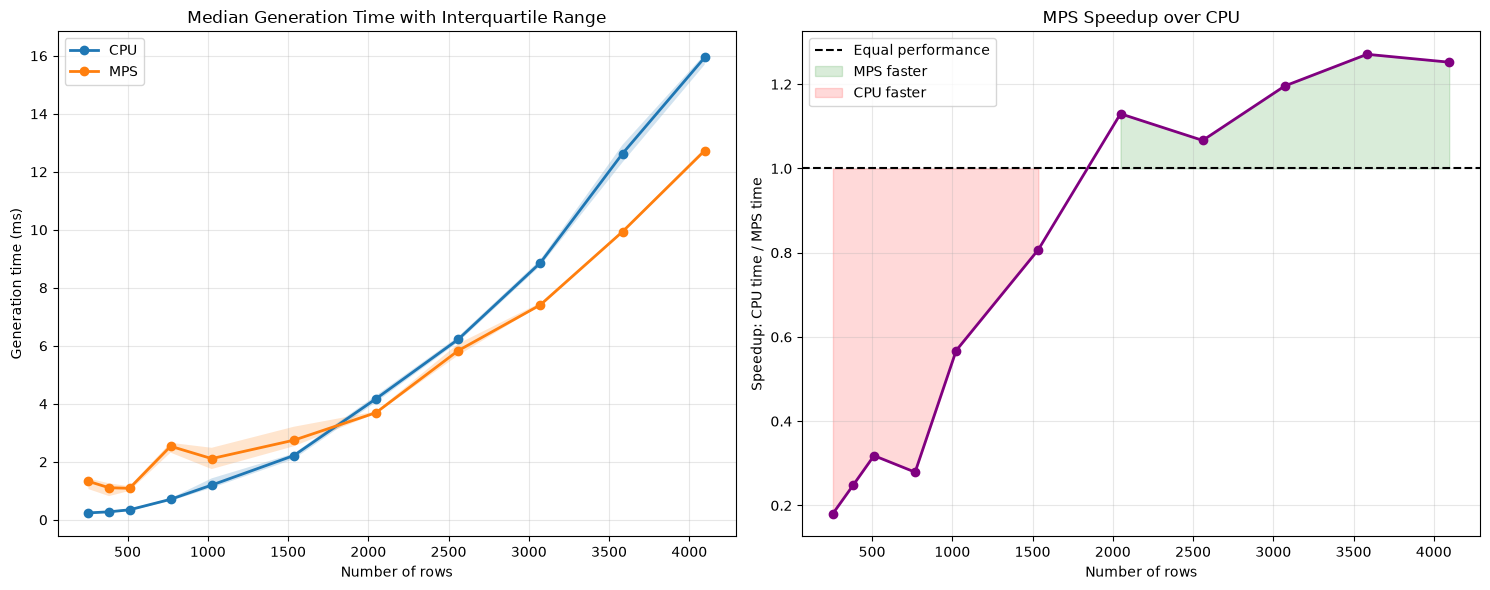

In [35]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Plot 1: execution time with interquartile ranges
for label in ["CPU", accelerator_label]:

    summary = benchmark_summary[label]

    axes[0].plot(
        benchmark_sizes,
        summary["median"],
        marker="o",
        linewidth=2,
        label=label
    )

    axes[0].fill_between(
        benchmark_sizes,
        summary["q1"],
        summary["q3"],
        alpha=0.2
    )

axes[0].set_xlabel("Number of rows")
axes[0].set_ylabel("Generation time (ms)")
axes[0].set_title(
    "Median Generation Time with Interquartile Range"
)
axes[0].grid(alpha=0.3)
axes[0].legend()


# Plot 2: accelerator speedup
axes[1].plot(
    benchmark_sizes,
    speedups,
    marker="o",
    color="purple",
    linewidth=2
)

axes[1].axhline(
    1.0,
    color="black",
    linestyle="--",
    label="Equal performance"
)

axes[1].fill_between(
    benchmark_sizes,
    speedups,
    1.0,
    where=(speedups >= 1.0),
    color="green",
    alpha=0.15,
    label=f"{accelerator_label} faster"
)

axes[1].fill_between(
    benchmark_sizes,
    speedups,
    1.0,
    where=(speedups < 1.0),
    color="red",
    alpha=0.15,
    label="CPU faster"
)

axes[1].set_xlabel("Number of rows")
axes[1].set_ylabel(
    f"Speedup: CPU time / {accelerator_label} time"
)
axes[1].set_title(
    f"{accelerator_label} Speedup over CPU"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Performance interpretation

The refined benchmark used 11 image sizes, 20 measured runs per device
and size, three warm-up runs, device synchronisation, and the median as
the representative execution time. The interquartile ranges show the
variability of the repeated measurements.

For small images, CPU execution is faster. The binary operations are
relatively lightweight, so the overhead of scheduling work on MPS is
larger than the benefit of accelerator parallelism.

In this benchmark run, the CPU remained faster up to 1536 rows. MPS
became faster at 2048 rows:

- CPU median time: 4.176 ms
- MPS median time: 3.696 ms
- MPS speedup: approximately 1.13 times

The MPS advantage became clearer for larger coordinate grids. At the
largest tested resolution of 4096 rows:

- CPU median time: 15.943 ms
- MPS median time: 12.731 ms
- MPS speedup: approximately 1.25 times
- execution-time reduction: approximately 20.1%

These results demonstrate that accelerator parallelism becomes useful
when the coordinate grid is sufficiently large. They also show that an
accelerator does not automatically improve small workloads because
device scheduling and memory-management overheads must first be
overcome.

The exact execution times can change between runs because of background
system activity, device temperature, memory allocation, and operating
system scheduling. However, the overall trend remains consistent: CPU
is more efficient for small workloads, while MPS becomes more
competitive for large workloads.

## Fractal-dimension analysis

A Sierpiński gasket is composed of three smaller copies of itself.
Each copy has one half of the original side length. Therefore, its
theoretical fractal dimension is

$$
D = \frac{\log(3)}{\log(2)} \approx 1.585.
$$

This value lies between one and two. The gasket is more complex than a
one-dimensional line, but it does not completely fill a two-dimensional
area.

The dimension is also estimated numerically using the **box-counting
method**. The binary image is divided into square boxes of side length
$s$, and the number of boxes containing at least one active point is
recorded as $N(s)$.

For a fractal,

$$
N(s) \propto \left(\frac{1}{s}\right)^D.
$$

Taking logarithms gives

$$
\log N(s) = D\log(1/s) + c.
$$

Therefore, the gradient of the log-log plot estimates the fractal
dimension.

The raw Pascal-triangle representation is used because its square shape
can be divided exactly into power-of-two boxes. The centred visualisation
contains the same active addresses and therefore represents the same
fractal structure.

In [36]:
import numpy as np


def count_occupied_boxes(binary_image, box_size):
    """
    Count square boxes that contain at least one active pixel.

    Parameters
    ----------
    binary_image : torch.Tensor
        Two-dimensional Boolean tensor containing the fractal.
    box_size : int
        Side length of each square box in pixels.

    Returns
    -------
    int
        Number of occupied boxes.
    """
    height, width = binary_image.shape

    usable_height = (height // box_size) * box_size
    usable_width = (width // box_size) * box_size

    cropped_image = binary_image[
        :usable_height,
        :usable_width
    ]

    boxes = cropped_image.reshape(
        usable_height // box_size,
        box_size,
        usable_width // box_size,
        box_size
    )

    # Each output value represents whether one box contains
    # at least one active point.
    occupied_boxes = boxes.any(dim=3).any(dim=1)

    return int(occupied_boxes.sum().item())


# Use a power-of-two image size so every scale divides the image exactly.
dimension_size = 1024

dimension_gasket, _ = generate_sierpinski(
    dimension_size,
    device
)

# Test ten dyadic scales: 1, 2, 4, ..., 512 pixels.
box_sizes = np.array(
    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512],
    dtype=np.int64
)

occupied_counts = np.array(
    [
        count_occupied_boxes(
            dimension_gasket,
            int(box_size)
        )
        for box_size in box_sizes
    ],
    dtype=np.float64
)

# Normalised inverse box scale: image size divided by box size.
inverse_scales = dimension_size / box_sizes

log_inverse_scales = np.log(inverse_scales)
log_occupied_counts = np.log(occupied_counts)

# The gradient of this line is the estimated box-counting dimension.
estimated_dimension, fitted_intercept = np.polyfit(
    log_inverse_scales,
    log_occupied_counts,
    1
)

theoretical_dimension = np.log(3) / np.log(2)
absolute_error = abs(
    estimated_dimension - theoretical_dimension
)

print("Box-counting results")
print("--------------------")

for box_size, count in zip(box_sizes, occupied_counts):
    print(
        f"Box size {box_size:3d}: "
        f"occupied boxes = {int(count):6d}"
    )

print()
print(
    f"Theoretical dimension: {theoretical_dimension:.6f}"
)
print(
    f"Estimated dimension:   {estimated_dimension:.6f}"
)
print(
    f"Absolute error:        {absolute_error:.6e}"
)

Box-counting results
--------------------
Box size   1: occupied boxes =  59049
Box size   2: occupied boxes =  19683
Box size   4: occupied boxes =   6561
Box size   8: occupied boxes =   2187
Box size  16: occupied boxes =    729
Box size  32: occupied boxes =    243
Box size  64: occupied boxes =     81
Box size 128: occupied boxes =     27
Box size 256: occupied boxes =      9
Box size 512: occupied boxes =      3

Theoretical dimension: 1.584963
Estimated dimension:   1.584963
Absolute error:        8.881784e-16


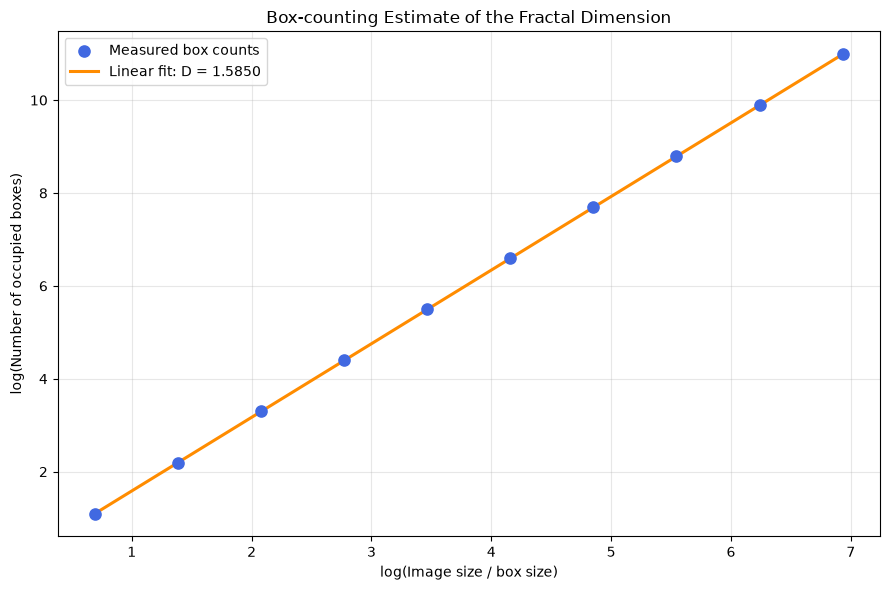

In [37]:
fitted_log_counts = (
    estimated_dimension * log_inverse_scales
    + fitted_intercept
)

# Sort the values so the fitted line is drawn from left to right.
plot_order = np.argsort(log_inverse_scales)

plt.figure(figsize=(9, 6))

plt.scatter(
    log_inverse_scales,
    log_occupied_counts,
    color="royalblue",
    s=65,
    label="Measured box counts",
    zorder=3
)

plt.plot(
    log_inverse_scales[plot_order],
    fitted_log_counts[plot_order],
    color="darkorange",
    linewidth=2.2,
    label=(
        "Linear fit: "
        f"D = {estimated_dimension:.4f}"
    )
)

plt.xlabel("log(Image size / box size)")
plt.ylabel("log(Number of occupied boxes)")
plt.title("Box-counting Estimate of the Fractal Dimension")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Fractal-dimension interpretation

The theoretical dimension of the Sierpiński gasket is

$$
D_{\mathrm{theory}}
=
\frac{\log(3)}{\log(2)}
\approx 1.584963.
$$

The box-counting experiment produced

$$
D_{\mathrm{estimated}}
\approx 1.584963.
$$

The absolute numerical difference was approximately

$$
8.88 \times 10^{-16}.
$$

This difference is effectively zero and is caused only by
floating-point rounding. The experimental estimate therefore agrees
with the theoretical dimension.

At every tested scale, doubling the box side length divided the number
of occupied boxes by three. For example:

| Box size | Occupied boxes |
|---:|---:|
| 1 | 59049 |
| 2 | 19683 |
| 4 | 6561 |
| 8 | 2187 |
| 16 | 729 |

This repeated scaling pattern demonstrates the self-similarity of the
Sierpiński gasket. Increasing the box size by a factor of two reduces
the occupied-box count by a factor of three.

The fitted points form a straight line on the log-log graph. Its
gradient is the estimated box-counting dimension:

$$
D
=
\frac{\log(3)}{\log(2)}
\approx 1.585.
$$

A dimension between one and two means that the gasket is more complex
than a one-dimensional line, but it does not completely fill a
two-dimensional area.

PyTorch performs the box analysis using tensor reshaping and parallel
Boolean reduction. The Python loop only changes the ten box scales;
the pixels within each scale are processed simultaneously on the
selected computational device.